<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/03_5_%EA%B5%B0%EC%A7%91.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 125082 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


## 01 k-평균 군집 (k-means)
- 데이터의 어떤 영역을 대표하는 **클러스터 중심** (cluster center)을 찾음
- 1️⃣ 데이터 포인트를 가장 가까운 클러스터 중심에 할당
- 2️⃣ 클러스터에 할당된 데이터 포인트의 평균으로 클러스터 중심을 다시 지정
- 3️⃣ 클러스터에 할당되는 데이터 포인트에 변화가 없을 때 알고리즘 종료

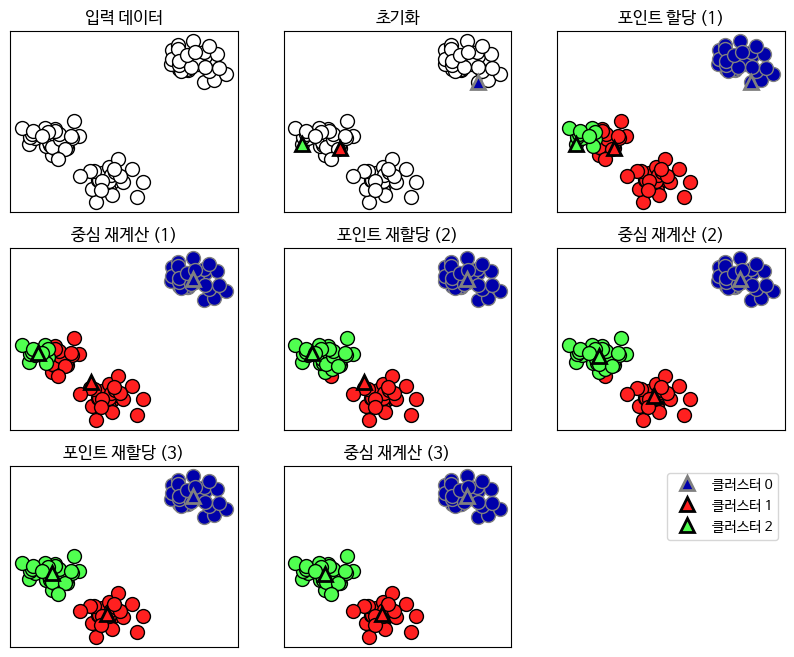

In [3]:
mglearn.plots.plot_kmeans_algorithm()

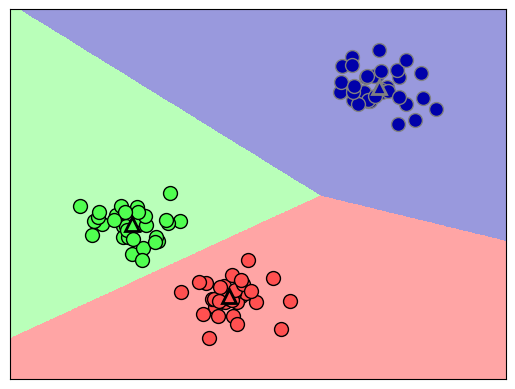

In [4]:
# k-평균 알고리즘으로 찾은 클러스터 중심과 클러스터 경계
mglearn.plots.plot_kmeans_boundaries()

### 1.1 k-평균 알고리즘 적용

In [5]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 2차원 데이터 생성
X, y = make_blobs(random_state=1)

# 군집 모델 생성
# n_clusters=3: 3개의 클러스터 (기본값 8)
kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

KMeans(n_clusters=3)

In [6]:
# 훈련 데이터 포인트에 클러스터 레이블이 할당
print(f"클러스터 레이블:\n{kmeans.labels_}")

클러스터 레이블:
[1 2 2 2 0 0 0 2 1 1 2 2 0 1 0 0 0 1 2 2 0 2 0 1 2 0 0 1 1 0 1 1 0 1 2 0 2
 2 2 0 0 2 1 2 2 0 1 1 1 1 2 0 0 0 1 0 2 2 1 1 2 0 0 2 2 0 1 0 1 2 2 2 0 1
 1 2 0 0 1 2 1 2 2 0 1 1 1 1 2 1 0 1 1 2 2 0 0 1 0 1]


In [7]:
# predict(): 새로운 데이터의 클러스터 레이블 예측
# 가장 가까운 클러스터 중심을 할당하는 것이며 기존 모델을 변경하지 않음
print(kmeans.predict(X))

[1 2 2 2 0 0 0 2 1 1 2 2 0 1 0 0 0 1 2 2 0 2 0 1 2 0 0 1 1 0 1 1 0 1 2 0 2
 2 2 0 0 2 1 2 2 0 1 1 1 1 2 0 0 0 1 0 2 2 1 1 2 0 0 2 2 0 1 0 1 2 2 2 0 1
 1 2 0 0 1 2 1 2 2 0 1 1 1 1 2 1 0 1 1 2 2 0 0 1 0 1]


- 분류와 비슷해 보이지만 다름!: 정답을 모르며 레이블 자체에 어떤 의미가 있지 않음

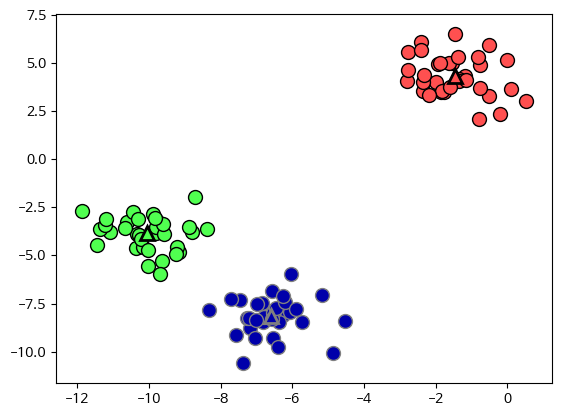

In [8]:
# k-평균 알고리즘으로 찾은 세 개의 클러스터 중심과 클러스터 할당
mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers="o")
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
    markers="^", markeredgewidth=2
)

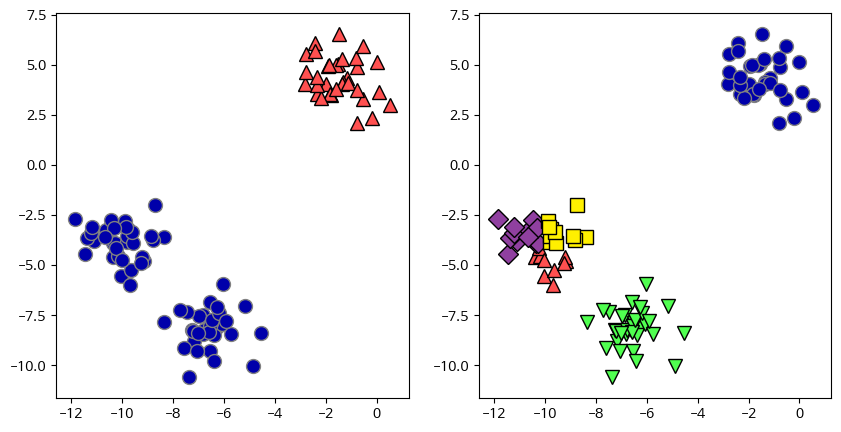

In [11]:
# k-평균 알고리즘으로 클러스터를 두 개 사용했을 때와 다섯 개 사용했을 때의 클러스터 할당
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for idx, i in enumerate([2, 5], start=0):
  kmeans = KMeans(n_clusters=i)
  kmeans.fit(X)
  assignments = kmeans.labels_

  mglearn.discrete_scatter(X[:, 0], X[:, 1], assignments, ax=axes[idx])

### 1.2 k-평균 알고리즘이 실패하는 경우
- 각 클러스터를 정의하는 것은 중심 하나뿐이므로 클러스터는 둥근 형태로 나타남 ➡️ 비교적 간단한 형태를 구분
- 모든 클러스터의 반경이 똑같다고 가정 ➡️ 클러스터 중심 사이의 정확히 중간에 경계를 그림

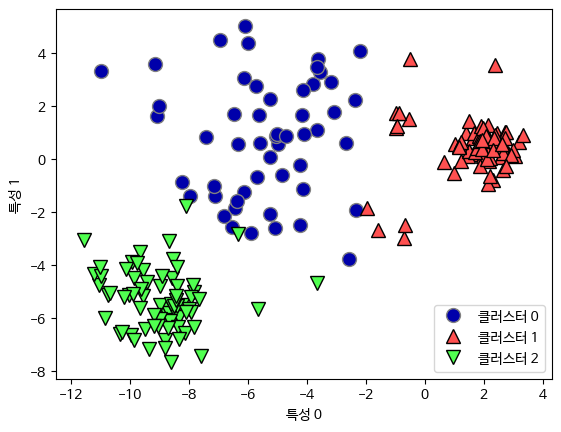

In [12]:
# 클러스터의 밀도가 다를 때 k-평균으로 찾은 클러스터 할당
X_varied, y_varied = make_blobs(n_samples=200,
                                cluster_std=[1.0, 2.5, 0.5],
                                random_state=170)
y_pred = KMeans(n_clusters=3, random_state=0).fit_predict(X_varied)
mglearn.discrete_scatter(X_varied[:, 0], X_varied[:, 1], y_pred)
plt.legend(["클러스터 0", "클러스터 1", "클러스터 2"], loc="best")
plt.xlabel("특성 0")
plt.ylabel("특성 1")
plt.show()

- 클러스터에서 모든 방향이 똑같이 중요하다고 가정 ➡️ 가장 가까운 클러스터 중심까지의 거리만 고려하기 때문에 대각선으로 늘어선 데이터를 잘 처리하지 못함

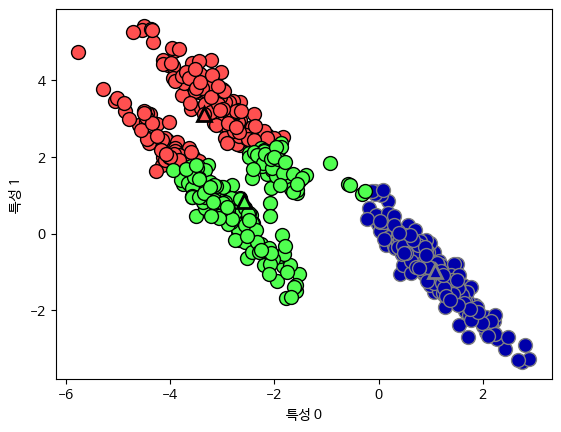

In [13]:
# 원형이 아닌 클러스터를 구분하지 못하는 k-평균 알고리즘

X, y = make_blobs(random_state=170, n_samples=600)
rng = np.random.RandomState(74)

# 데이터가 길게 늘어지도록 변경
transformation = rng.normal(size=(2, 2))
X = np.dot(X, transformation)

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
y_pred = kmeans.predict(X)

mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers="o")
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2],
    markers="^", markeredgewidth=2
)
plt.xlabel("특성 0")
plt.ylabel("특성 1")
plt.show()

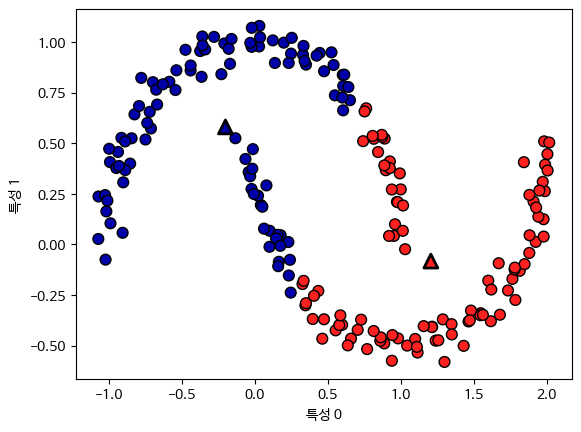

In [17]:
# 복잡한 모양의 클러스터를 구분하지 못하는 k-평균 알고리즘
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

kmeans = KMeans(n_clusters=2)
kmeans.fit(X)
y_pred = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred,
            cmap=mglearn.cm2, s=60, edgecolors="k")
plt.scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    marker="^", c=[mglearn.cm2(0), mglearn.cm2(1)], s=100,
    linewidth=2, edgecolors="k"
)
plt.xlabel("특성 0")
plt.ylabel("특성 1")
plt.show()

### 1.3 벡터 양자화 또는 분해 메서드로서의 k-평균
- PCA, NMF
  - PCA: 데이터에서 분산이 가장 큰 방향을 찾음
  - NMF: 데이터의 극단 또는 일부분에 상응되는 중첩할 수 있는 성분을 찾음
  - 데이터 포인트를 어떤 성분의 합으로 표현
- k-평균
  - 클러스터 중심으로 각 데이터 포인트를 표현
  - 각 데이터 포인트가 클러스터 중심, 즉 하나의 성분으로 표현됨
- **벡터 양자화**(vector quantization): k-평균을 각 포인트가 하나의 성분으로 분해되는 관점으로 보는 것


In [20]:
# 데이터 로드
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people(min_faces_per_person=20, resize=0.7)

# 편중 제거
mask = np.zeros(people.target.shape, dtype=bool)
for target in np.unique(people.target):
  mask[np.where(people.target == target)[0][:50]] = 1

X_people = people.data[mask]
y_people = people.target[mask]

X_people = X_people/225.

In [22]:
# PCA, NMF, k-평균에서 추출한 성분과 이미지 재구성 비교
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, NMF

X_train, X_test, y_train, y_test = train_test_split(
    X_people, y_people, stratify=y_people, random_state=42
)

# pca
pca = PCA(n_components=100, random_state=0)
pca.fit(X_train)

# nmf
nmf = NMF(n_components=100, init="nndsvd", random_state=0,
          max_iter=1000, tol=1e-2)
nmf.fit(X_train)

# kmeans
kmeans = KMeans(n_clusters=100, random_state=0)
kmeans.fit(X_train)

X_reconstructed_pca = pca.inverse_transform(pca.transform(X_test))
X_reconstructed_nmf = np.dot(nmf.transform(X_test), nmf.components_)
X_reconstructed_kmeans = kmeans.cluster_centers_[kmeans.predict(X_test)]

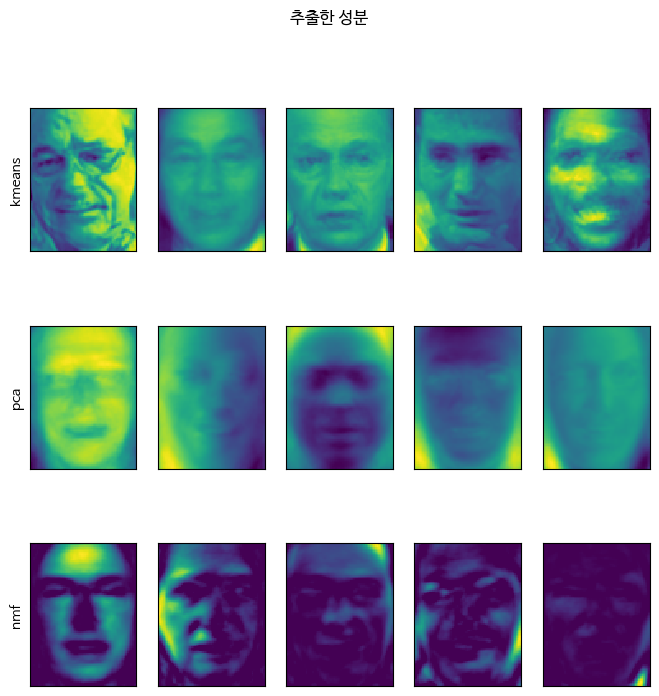

In [27]:
# PCA, NMF, k-평균에서 추출한 성분 비교

fig, axes = plt.subplots(3, 5, figsize=(8, 8), subplot_kw={"xticks": (), "yticks": ()})
fig.suptitle("추출한 성분")
image_shape = people.images[0].shape
for ax, comp_kmeans, comp_pca, comp_nmf in zip(
    axes.T, kmeans.cluster_centers_, pca.components_, nmf.components_):
  ax[0].imshow(comp_kmeans.reshape(image_shape))
  ax[1].imshow(comp_pca.reshape(image_shape), cmap="viridis")
  ax[2].imshow(comp_nmf.reshape(image_shape))

axes[0, 0].set_ylabel("kmeans")
axes[1, 0].set_ylabel("pca")
axes[2, 0].set_ylabel("nmf")

plt.show()

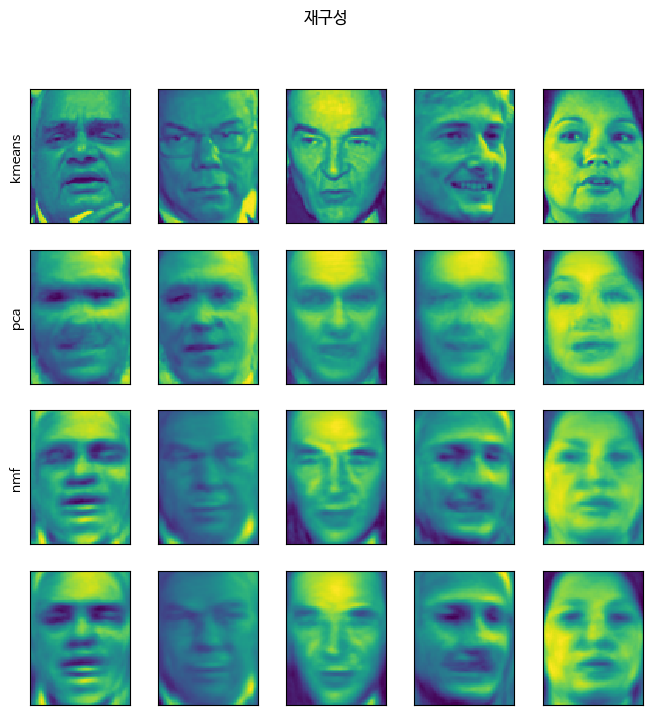

In [28]:
# PCA, NMF, k-평균의 이미지 재구성 비교

fig, axes = plt.subplots(4, 5, figsize=(8, 8), subplot_kw={"xticks": (), "yticks": ()})
fig.suptitle("재구성")

for ax, orig, rec_kmeans, rec_pca, rec_nmf in zip(
    axes.T, X_test, X_reconstructed_kmeans, X_reconstructed_pca,
    X_reconstructed_nmf):
  ax[0].imshow(orig.reshape(image_shape))
  ax[1].imshow(rec_kmeans.reshape(image_shape))
  ax[2].imshow(rec_pca.reshape(image_shape))
  ax[3].imshow(rec_nmf.reshape(image_shape))

axes[0, 0].set_ylabel("원본")
axes[0, 0].set_ylabel("kmeans")
axes[1, 0].set_ylabel("pca")
axes[2, 0].set_ylabel("nmf")

plt.show()

- k-평균을 사용한 벡터 양자화: 입력 데이터의 차원보다 더 많은 클러스터를 사용해 데이터 인코딩 가능
- 2차원 데이터에서 PCA, NMF를 사용해 1차원으로 축소하면 데이터의 구조가 완전히 파괴되지만, K-평균은 데이터를 더 잘 표현할 수 있음

클러스터 레이블:
[8 4 6 3 1 1 5 2 8 4 9 2 1 4 7 5 0 2 0 7 1 2 0 4 9 6 1 1 6 0 8 9 2 6 8 1 2
 5 3 6 2 7 8 6 4 9 5 7 6 2 7 2 1 3 4 8 0 4 0 9 2 3 1 8 4 3 9 4 9 3 2 3 2 6
 2 3 6 8 0 2 1 9 2 1 6 9 5 9 2 1 0 5 1 7 1 1 4 2 3 6 4 1 9 5 3 6 3 7 4 0 7
 9 9 3 8 4 8 1 2 8 8 7 6 9 6 7 5 6 4 1 5 7 3 6 4 4 4 3 1 8 6 6 0 9 7 5 6 4
 0 6 2 4 8 0 2 9 4 2 0 0 6 4 0 4 2 1 0 2 4 2 0 3 3 7 6 2 1 7 7 0 4 3 1 4 1
 0 9 2 3 7 3 0 8 5 6 7 1 6 9 4]


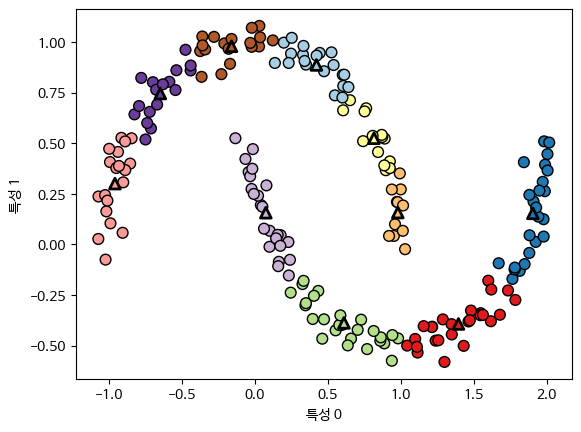

In [30]:
X,y = make_moons(n_samples=200, noise=0.05, random_state=0)
kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(X)
y_pred = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=60, cmap="Paired", edgecolors="black")
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=60,
            marker="^", c=range(kmeans.n_clusters), linewidth=2, cmap="Paired",
            edgecolors="black")
plt.xlabel("특성 0")
plt.ylabel("특성 1")
print(f"클러스터 레이블:\n{y_pred}")
plt.show()

- 데이터를 10개의 성분 (10개의 특성)으로 표현한 것
- 10차원 형태를 이용하면 선형 모델을 사용해 두 개의 반달 모양을 구분할 수 있을 것
- 클러스터 중심까지의 거리를 특성으로 사용하면 데이터를 더 잘 나타낼 수 있음

In [31]:
# transform(): 클러스터 중심까지의 거리
distance_features = kmeans.transform(X)
print(f"클러스터 거리 데이터의 형태: {distance_features.shape}")
print(f"클러스터 거리:\n{distance_features}")

클러스터 거리 데이터의 형태: (200, 10)
클러스터 거리:
[[0.537 1.15  0.932 ... 1.48  0.003 1.077]
 [1.741 0.606 1.007 ... 2.529 1.208 2.237]
 [0.757 1.931 0.916 ... 0.783 0.876 0.718]
 ...
 [0.927 1.738 0.579 ... 1.115 0.834 1.041]
 [0.323 1.976 1.479 ... 0.814 0.846 0.284]
 [1.633 0.472 1.023 ... 2.466 1.098 2.148]]


### 1.4 장단점
- 장점
  - 비교적 이해하기 쉬움
  - 쉬운 구현
  - 비교적 빠름
  - 대용량 데이터셋에도 잘 작동
  - ➡️ 가장 인기있는 군집 알고리즘
  - `MiniBatchKmeans`: 아주 큰 대규모 데이터셋 처리 가능
- 단점
  - 무작위 초기화를 사용하여 알고리즘의 출력이 난수 초깃값에 따라 달라짐
  - 클러스터의 모양을 가정하고 있어서 활용 범위가 비교적 제한적
  - 찾으려 하는 클러스터의 개수를 지정해야만 함

### 1.5 엘보우 방법 (elbow method)
- 클러스터 개수를 선택하는 방법
- 클러스터 개수를 늘려가면서 k-평균의 이너셔(inertia) 감소가 완만해지는 지점을 찾음
- 이너셔: 클러스터 중심에서 클러스터에 속한 각 샘플간의 제곱 거리의 합

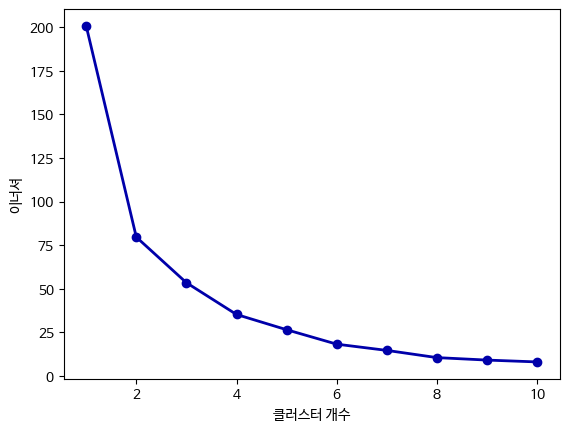

In [33]:
inertia = []
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, random_state=0)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("클러스터 개수")
plt.ylabel("이너셔")
plt.show()

- 적절한 클러스터 개수는 2 ~ 4 사이